# Cluster Interpretation

**Domanda**: cosa distingue i soggetti di un cluster dagli altri, clinicamente e anatomicamente?

- **Legge**: una run di clustering già prodotta (`results/<lesion|sdc>/clustering/production/...`),
  `assets/metadata/participants.csv` e i file `.nii.gz` dei soggetti in `data/clinical_connectome/derivatives`.
- **Scrive**: nulla.
- **Non fa**: non valuta la qualità della run (`clustering_evaluation.ipynb`) né confronta più run
  (`clustering_comparison.ipynb`).

Replica le analisi del pannello "Descrizione del cluster" e dei pannelli anatomici dell'app Dash
(`src/analysis/embedding_app.py`), riusando le stesse funzioni (`cluster_description`, `anatomical_maps`), così i
numeri coincidono. È il posto dove provare analisi nuove prima di portarle nell'app: l'ultima sezione elenca cosa
c'è già nell'app e cosa è solo qui.

Si sceglie all'inizio **la run** (`RUN_KEY`) e **il cluster** (`CLUSTER`). Se la run è `sdc` si attivano anche le
mappe di disconnessione.

| Sezione | Contenuto | Nell'app |
|---|---|---|
| 3 | Caratterizzazione demografica e clinica | sì (tabella e figura) |
| 4 | Composizione: dataset, lato, localizzazione della lesione | solo qui |
| 5 | Mappe anatomiche: overlap e probabilità (lesione, SDC), differenza cluster − resto | overlap e frequenza sì, differenza solo qui |
| 6 | Soggetti rappresentativi | sì |
| 7 | Cluster contro resto: test ed effect size | solo qui |

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
from nilearn import plotting as nilearn_plotting
from scipy import stats

# Repo root isn't on sys.path when this notebook runs with cwd=notebooks/post-results_analysis/ -
# needed for the `from src...` imports below.
NOTEBOOK_REPO_ROOT = Path.cwd().resolve().parents[1]
if str(NOTEBOOK_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_REPO_ROOT))
# cluster_composition e load_participants_registry leggono assets/metadata/participants.csv con un path relativo
# alla repo root, come quando l'app parte da lì.
os.chdir(NOTEBOOK_REPO_ROOT)

from src.analysis.anatomical_maps import (
    BinaryMaskStore, build_mean_map, build_overlap_map, resolve_available_lesion_paths,
)
from src.analysis.build_config import load_build_matrix_config
from src.analysis.cluster_description import (
    CLUSTER_DESCRIPTION_VARIABLES, ClusterDescriptionVariable,
    build_cluster_description_figure, cluster_composition, variable_summary,
)
from src.analysis.embedding_app import (
    DISCONNECTION_PROBABILITY_THRESHOLD, SDC_DISCONNECTOME_GLOB, LesionViewerConfig, SdcViewerConfig,
    UndisplayableRunError, cluster_options, discover_production_runs, load_run, run_metadata,
)
from src.features.lesion import load_reference_image
from src.utils.participants import load_participants_registry

# src.analysis.* imposta matplotlib.use("Agg") al proprio import: senza questo i plot non compaiono.
%matplotlib inline

sns.set_theme(style="whitegrid")

## 1. Configurazione

Le stesse configurazioni che l'app costruisce all'avvio (`src/pipeline/embedding_app.py`).

- **Lesione**: da `config/pipelines/build_lesion_matrix.json` (cartella dati, glob delle maschere, griglia 2mm di
  riferimento, soglia di binarizzazione).
- **SDC**: l'app legge `build_sdc_matrix.json`, ma oggi quel file è `streamline` e non ha un template di riferimento.
  Qui la griglia è dichiarata esplicitamente: la stessa 2mm della lesione e `nearest`, come le matrici `s2.x-vol`.
- `INTERACTIVE_MAPS = True` sostituisce le mappe statiche con il viewer interattivo dell'app (pesante: ogni mappa
  salva diversi MB nel notebook).

In [2]:
INTERACTIVE_MAPS = False
DIFFERENCE_THRESHOLD = 5.0  # punti percentuali: sotto questa differenza |cluster - resto| la mappa non colora il voxel
SDC_RESAMPLE_INTERPOLATION = "nearest"

lesion_matrix_config = load_build_matrix_config(NOTEBOOK_REPO_ROOT / "config/pipelines/build_lesion_matrix.json")
data_root = NOTEBOOK_REPO_ROOT / lesion_matrix_config.data_root
reference_img = load_reference_image(NOTEBOOK_REPO_ROOT / lesion_matrix_config.reference_template_path)

lesion_cfg = LesionViewerConfig(
    data_root=data_root,
    lesion_glob=lesion_matrix_config.lesion_glob,
    reference_img=reference_img,
    binarize_threshold=lesion_matrix_config.binarize_threshold,
    resample_interpolation=lesion_matrix_config.resample_interpolation,
)
sdc_cfg = SdcViewerConfig(
    data_root=data_root,
    disconnectome_glob=SDC_DISCONNECTOME_GLOB,
    reference_img=reference_img,
    resample_interpolation=SDC_RESAMPLE_INTERPOLATION,
)

# Una memoria per tipo di mappa: un soggetto già visto non si rilegge dal disco per i cluster successivi.
lesion_store = BinaryMaskStore(lesion_cfg.reference_img, lesion_cfg.resample_interpolation, lesion_cfg.binarize_threshold)
sdc_store = BinaryMaskStore(sdc_cfg.reference_img, sdc_cfg.resample_interpolation, DISCONNECTION_PROBABILITY_THRESHOLD)

## 2. Scelta della run e del cluster

1. La tabella elenca le run di clustering disponibili (`MODALITY_FILTER`/`METHOD_FILTER` la restringono).
2. Si copia la `key` della run in `RUN_KEY` e si sceglie `CLUSTER`.
3. Se la run è `sdc`, `SHOW_SDC_MAPS` si attiva da solo (mettilo a `True` per vederle anche su una run `lesion`: i
   soggetti hanno quasi sempre anche il disconnettoma).

Per hdbscan il rumore (`-1`) è un cluster selezionabile come gli altri: è il gruppo dei soggetti non assegnati.

In [3]:
MODALITY_FILTER = None  # "lesion" | "sdc" | None
METHOD_FILTER = None    # es. "kmeans" | None

clustering_runs = [r for r in discover_production_runs(NOTEBOOK_REPO_ROOT / "results") if r.pipeline == "clustering"]
available = pd.DataFrame(
    [{"key": r.key, "modality": r.modality, "method": r.method, "reduction": r.reduction_method, "run": r.run_name}
     for r in clustering_runs]
)
if MODALITY_FILTER is not None:
    available = available[available["modality"] == MODALITY_FILTER]
if METHOD_FILTER is not None:
    available = available[available["method"] == METHOD_FILTER]
with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
    display(available.set_index("key"))

,modality,method,reduction,run
key,,,,
lesion/clustering/agglomerative/umap/01-09_s1.1-vol_m_euclidean_nc2_k4_link_average,lesion,agglomerative,umap,01-09_s1.1-vol_m_euclidean_nc2_k4_link_average
lesion/clustering/agglomerative/umap/01-09_s1.1-vol_m_euclidean_nc2_k5_link_average,lesion,agglomerative,umap,01-09_s1.1-vol_m_euclidean_nc2_k5_link_average
lesion/clustering/agglomerative/umap/01-09_s1.1-vol_m_euclidean_nc2_k6_link_average,lesion,agglomerative,umap,01-09_s1.1-vol_m_euclidean_nc2_k6_link_average
lesion/clustering/agglomerative/umap/03-09_s1.2-vol_m_euclidean_nc2_k4_link_average,lesion,agglomerative,umap,03-09_s1.2-vol_m_euclidean_nc2_k4_link_average
lesion/clustering/agglomerative/umap/03-09_s1.2-vol_m_euclidean_nc2_k5_link_average,lesion,agglomerative,umap,03-09_s1.2-vol_m_euclidean_nc2_k5_link_average
lesion/clustering/agglomerative/umap/03-09_s1.2-vol_m_euclidean_nc2_k6_link_average,lesion,agglomerative,umap,03-09_s1.2-vol_m_euclidean_nc2_k6_link_average
lesion/clustering/gmm/umap/01-09_s1.1-vol_m_euclidean_nc2_n_comp4_cov_full,lesion,gmm,umap,01-09_s1.1-vol_m_euclidean_nc2_n_comp4_cov_full
lesion/clustering/gmm/umap/01-09_s1.1-vol_m_euclidean_nc2_n_comp5_cov_full,lesion,gmm,umap,01-09_s1.1-vol_m_euclidean_nc2_n_comp5_cov_full
lesion/clustering/gmm/umap/01-09_s1.1-vol_m_euclidean_nc2_n_comp6_cov_full,lesion,gmm,umap,01-09_s1.1-vol_m_euclidean_nc2_n_comp6_cov_full


In [4]:
RUN_KEY = "sdc/clustering/kmeans/umap/10-09_s2.2-vol_m_euclidean_nc2_k4"
CLUSTER = 0

run = next((r for r in clustering_runs if r.key == RUN_KEY), None)
if run is None:
    raise ValueError(f"RUN_KEY {RUN_KEY!r} non è una run di clustering: copia una `key` dalla tabella sopra")

metadata = run_metadata(run)
if CLUSTER not in cluster_options(metadata):
    raise ValueError(f"CLUSTER={CLUSTER} non esiste in questa run, cluster disponibili: {cluster_options(metadata)}")

SHOW_SDC_MAPS = run.modality == "sdc"

sizes = metadata["cluster_label"].value_counts().sort_index()
print(f"{run.key}\nmodalità: {run.modality} | soggetti: {len(metadata)} | SHOW_SDC_MAPS={SHOW_SDC_MAPS}")
pd.DataFrame({"n": sizes, "%": (100 * sizes / len(metadata)).round(1)}).rename_axis("cluster")

sdc/clustering/kmeans/umap/10-09_s2.2-vol_m_euclidean_nc2_k4
modalità: sdc | soggetti: 1570 | SHOW_SDC_MAPS=True


,n,%
cluster,,
0,421,26.8
1,476,30.3
2,282,18.0
3,391,24.9


## Utils

Funzioni usate dalle sezioni sotto, definite una volta. Le sezioni contengono solo l'applicazione.

In [5]:
# Le variabili del pannello "Descrizione del cluster" dell'app, più due colonne di disconnessione che l'app non mostra.
# variable_summary legge solo composition[variable.name], quindi accetta anche variabili aggiunte qui.
EXTRA_VARIABLES = [
    ClusterDescriptionVariable(
        "disconnection_load", "Carico di disconnessione (voxel, 2mm)", "continuous", "disconnection_load_voxels_2mm",
        decimals=0, color="#1a6bab",
    ),
    ClusterDescriptionVariable(
        "disconnection_mean", "Disconnessione media (2mm)", "continuous", "disconnection_mean_2mm",
        decimals=3, color="#d97a29",
    ),
]
VARIABLES = CLUSTER_DESCRIPTION_VARIABLES + EXTRA_VARIABLES

CATEGORICAL_COLUMNS = {"dataset": "dataset", "lesion_side": "lesion_side", "location_dominant": "location_dominant_2mm"}
LOCATION_FRACTION_COLUMNS = {
    "infratentorial": "location_infratentorial_2mm",
    "subcortical_gray": "location_subcortical_gray_2mm",
    "cortex_only": "location_cortex_only_2mm",
    "cortex_white_boundary": "location_cortex_white_boundary_2mm",
    "white_matter_only": "location_white_matter_only_2mm",
    "ventricle": "location_ventricle_2mm",
    "unlabeled": "location_unlabeled_2mm",
}


def registry_frame(run_metadata_frame: pd.DataFrame) -> pd.DataFrame:
    """Una riga per soggetto della run: cluster_label e ogni variabile letta da participants.csv (mai dal
    metadata.csv della run, come l'app: docs/dev/cluster_description.md). Un soggetto assente dal registro resta,
    con valori mancanti, e viene segnalato."""
    registry = load_participants_registry().set_index("subject_id")
    subject_ids = run_metadata_frame["subject_id"].to_numpy()
    unregistered = sorted(set(subject_ids) - set(registry.index))
    if unregistered:
        print(f"{len(unregistered)}/{len(subject_ids)} soggetti senza riga in participants.csv: {unregistered}")

    aligned = registry.reindex(subject_ids)
    frame = pd.DataFrame({"subject_id": subject_ids, "cluster_label": run_metadata_frame["cluster_label"].to_numpy()})
    for variable in VARIABLES:
        raw = aligned[variable.registry_column].to_numpy()
        frame[variable.name] = pd.to_numeric(raw, errors="coerce") if variable.kind == "continuous" else raw
    for name, column in CATEGORICAL_COLUMNS.items():
        frame[name] = aligned[column].replace("", np.nan).to_numpy()
    for name, column in LOCATION_FRACTION_COLUMNS.items():
        frame[f"loc_{name}"] = pd.to_numeric(aligned[column].to_numpy(), errors="coerce")
    return frame


def format_summary(summary: dict, variable: ClusterDescriptionVariable) -> str:
    """Una cella della tabella di confronto: media ± std (continua) o quote % (categorica), con n disponibili/totali."""
    n_text = f"n={summary['n_available']}/{summary['n_total']}"
    if variable.kind == "continuous":
        if summary["mean"] is None:
            return f"— ({n_text})"
        spread = f" ± {summary['std']:.{variable.decimals}f}" if summary["std"] is not None else ""
        return f"{summary['mean']:.{variable.decimals}f}{spread} ({n_text})"
    if not summary["n_available"]:
        return f"— ({n_text})"
    shares = " / ".join(f"{k} {100 * v / summary['n_available']:.0f}%" for k, v in sorted(summary["counts"].items()))
    return f"{shares} ({n_text})"


def composition_counts(column: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """(conteggi, % per riga) di cluster_label x column. I valori mancanti di column non sono una categoria."""
    counts = pd.crosstab(frame["cluster_label"], frame[column])
    return counts, counts.div(counts.sum(axis=1), axis=0) * 100


def cramers_v(counts: pd.DataFrame) -> tuple[float, float]:
    """(V di Cramér, p del chi-quadro) della tabella cluster x categoria. Solleva se la tabella ha meno di 2 righe/colonne."""
    if counts.shape[0] < 2 or counts.shape[1] < 2:
        raise ValueError(f"serve una tabella almeno 2x2, trovata {counts.shape}")
    chi2, p_value, _dof, _expected = stats.chi2_contingency(counts)
    return float(np.sqrt(chi2 / (counts.to_numpy().sum() * (min(counts.shape) - 1)))), float(p_value)


def plot_composition(row_pct: pd.DataFrame, title: str) -> None:
    """Barre orizzontali al 100%: la composizione di ogni cluster. Il cluster scelto ha l'etichetta in grassetto."""
    ax = row_pct.plot(kind="barh", stacked=True, figsize=(9, 0.55 * len(row_pct) + 2), colormap="tab10", width=0.8)
    ax.set_xlabel("% del cluster")
    ax.set_ylabel("cluster")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.grid(False)
    for tick in ax.get_yticklabels():
        if tick.get_text() == str(CLUSTER):
            tick.set_fontweight("bold")
    plt.show()

In [6]:
def resolve_paths(subjects: pd.DataFrame, data_root: Path, glob_pattern: str) -> tuple[dict[str, Path], list[str]]:
    """File sul disco di oggi per i soggetti dati. Un soggetto non trovato è escluso e restituito in `missing`
    (come i pannelli per-cluster dell'app); solleva solo se non se ne trova nessuno."""
    dataset_by_subject = dict(zip(subjects["subject_id"], subjects["dataset"]))
    return resolve_available_lesion_paths(list(dataset_by_subject), dataset_by_subject, data_root, glob_pattern)


def lesion_overlap(subjects: pd.DataFrame) -> tuple[nib.Nifti1Image, nib.Nifti1Image, int, list[str]]:
    """(count_img, percentage_img, n usati, mancanti): per voxel, quanti soggetti e che % hanno la lesione."""
    paths, missing = resolve_paths(subjects, lesion_cfg.data_root, lesion_cfg.lesion_glob)
    count_img, percentage_img = build_overlap_map(
        paths, lesion_cfg.reference_img, lesion_cfg.binarize_threshold, lesion_cfg.resample_interpolation, store=lesion_store
    )
    return count_img, percentage_img, len(paths), missing


def sdc_maps(subjects: pd.DataFrame) -> tuple[nib.Nifti1Image, nib.Nifti1Image, nib.Nifti1Image, int, list[str]]:
    """(count_img, percentage_img, mean_img, n usati, mancanti) del disconnettoma. percentage_img binarizza ogni
    soggetto a DISCONNECTION_PROBABILITY_THRESHOLD (stessa grandezza dell'overlap della lesione: % di soggetti
    disconnessi nel voxel); mean_img è la media delle probabilità continue, che NON è una % di soggetti."""
    paths, missing = resolve_paths(subjects, sdc_cfg.data_root, sdc_cfg.disconnectome_glob)
    count_img, percentage_img = build_overlap_map(
        paths, sdc_cfg.reference_img, DISCONNECTION_PROBABILITY_THRESHOLD, sdc_cfg.resample_interpolation, store=sdc_store
    )
    mean_img = build_mean_map(paths, sdc_cfg.reference_img, sdc_cfg.resample_interpolation)
    return count_img, percentage_img, mean_img, len(paths), missing


_total_counts_cache: dict[str, tuple[nib.Nifti1Image, int]] = {}


def total_counts(kind: str) -> tuple[nib.Nifti1Image, int]:
    """(count_img, n) su tutti i soggetti della run, per "lesion" o "sdc". La prima chiamata legge ogni soggetto
    (poi restano in memoria nello store): è la parte lenta della mappa differenziale."""
    if kind not in ("lesion", "sdc"):
        raise ValueError(f"kind deve essere 'lesion' o 'sdc', ricevuto {kind!r}")
    if kind not in _total_counts_cache:
        if kind == "lesion":
            count_img, _pct, n, _missing = lesion_overlap(metadata)
        else:
            count_img, _pct, _mean, n, _missing = sdc_maps(metadata)
        _total_counts_cache[kind] = (count_img, n)
    return _total_counts_cache[kind]


def difference_map(cluster_count_img: nib.Nifti1Image, n_cluster: int, kind: str) -> nib.Nifti1Image:
    """% nel cluster meno % nel resto della run, per voxel (punti percentuali). Positivo = più frequente nel cluster.
    Solleva se il resto è vuoto (la run ha un cluster solo, o i soggetti del resto non sono sul disco)."""
    total_img, n_total = total_counts(kind)
    n_rest = n_total - n_cluster
    if n_rest <= 0:
        raise ValueError(f"nessun soggetto fuori dal cluster (n_total={n_total}, n_cluster={n_cluster})")
    cluster_counts = np.asarray(cluster_count_img.dataobj, dtype=np.float64)
    rest_counts = np.asarray(total_img.dataobj, dtype=np.float64) - cluster_counts
    difference = 100 * cluster_counts / n_cluster - 100 * rest_counts / n_rest
    return nib.Nifti1Image(difference.astype(np.float32), cluster_count_img.affine)


def peak(img: nib.Nifti1Image) -> tuple[float, tuple[int, int, int]]:
    """(valore massimo, coordinate MNI mm) di una mappa."""
    data = img.get_fdata()
    index = np.unravel_index(np.argmax(data), data.shape)
    return float(data[index]), tuple(int(round(v)) for v in nib.affines.apply_affine(img.affine, index))


def show_map(img: nib.Nifti1Image, title: str, cmap: str, threshold: float, symmetric: bool = False) -> None:
    """Mappa statica (3 fette ortogonali) o, con INTERACTIVE_MAPS, il viewer interattivo dell'app."""
    if INTERACTIVE_MAPS:
        display(nilearn_plotting.view_img(
            img, bg_img="MNI152", black_bg=False, threshold=threshold, cmap=cmap, symmetric_cmap=symmetric, title=title,
        ))
        return
    nilearn_plotting.plot_stat_map(img, title=title, cmap=cmap, threshold=threshold, colorbar=True)
    plt.show()


def report_missing(missing: list[str]) -> None:
    if missing:
        print(f"{len(missing)} soggetti senza file sul disco, esclusi dalla mappa: {missing}")

In [7]:
def nearest_subjects(embedding: np.ndarray, cluster_label: int, n: int) -> pd.DataFrame:
    """Gli n soggetti reali più vicini al centroide del cluster, nello spazio embedding (euclidea), dal più vicino.
    Il centroide è un punto medio, non un soggetto. Solleva se n supera la dimensione del cluster."""
    in_cluster = (metadata["cluster_label"] == cluster_label).to_numpy()
    if n > in_cluster.sum():
        raise ValueError(f"n={n} supera i {int(in_cluster.sum())} soggetti del cluster {cluster_label}")
    points = embedding[in_cluster]
    distances = np.linalg.norm(points - points.mean(axis=0), axis=1)
    order = np.argsort(distances)[:n]
    selected = metadata.loc[in_cluster, ["subject_id", "dataset"]].iloc[order].copy()
    selected["distance_to_centroid"] = distances[order]
    return selected.reset_index(drop=True)


def plot_subject_maps(subject_id: str, dataset: str, with_sdc: bool) -> None:
    """Maschera di lesione reale del soggetto e, se with_sdc, il suo disconnettoma reale (stessi cmap e soglie dell'app)."""
    n_rows = 2 if with_sdc else 1
    fig, axes = plt.subplots(n_rows, 1, figsize=(8, 3.4 * n_rows), squeeze=False)
    subject = pd.DataFrame({"subject_id": [subject_id], "dataset": [dataset]})

    lesion_paths, _missing = resolve_paths(subject, lesion_cfg.data_root, lesion_cfg.lesion_glob)
    nilearn_plotting.plot_stat_map(
        str(lesion_paths[subject_id]), title=f"{subject_id} - lesione", cmap="autumn",
        threshold=lesion_cfg.binarize_threshold, colorbar=False, axes=axes[0, 0],
    )
    if with_sdc:
        sdc_paths, _missing = resolve_paths(subject, sdc_cfg.data_root, sdc_cfg.disconnectome_glob)
        nilearn_plotting.plot_stat_map(
            str(sdc_paths[subject_id]), title=f"{subject_id} - disconnettoma", cmap="magma",
            threshold=0.02, colorbar=True, axes=axes[1, 0],
        )
    plt.show()

## 3. Caratterizzazione demografica e clinica

Le variabili sono quelle del pannello "Descrizione del cluster" (età, sesso, istruzione, NIHSS, volume della lesione),
più il carico e la media di disconnessione. Tutte da `participants.csv`, mai dal `metadata.csv` della run.

Ogni cella riporta `n=disponibili/totali`: una variabile poco coperta (istruzione, NIHSS) va letta insieme alla sua
copertura, non come se valesse per tutto il cluster.

In [8]:
frame = registry_frame(metadata)
frame.groupby("cluster_label").size().rename("n").to_frame().T

cluster_label,0,1,2,3
n,421,476,282,391


### 3.1 Confronto tra tutti i cluster

Una riga per cluster, la riga del cluster scelto è evidenziata. Continue: media ± deviazione standard. Sesso: quota %.

In [9]:
rows = []
for label, group in frame.groupby("cluster_label"):
    row = {"cluster": label, "n": len(group)}
    for variable in VARIABLES:
        row[variable.label] = format_summary(variable_summary(group, variable), variable)
    rows.append(row)

comparison = pd.DataFrame(rows).set_index("cluster")
comparison.style.apply(
    lambda row: ["font-weight: bold; background-color: #fff3cd" if row.name == CLUSTER else "" for _ in row], axis=1
)

,n,Età (anni),Sesso,Istruzione (anni),NIHSS,Volume lesione (voxel),"Carico di disconnessione (voxel, 2mm)",Disconnessione media (2mm)
cluster,,,,,,,,
0,421,65.8 ± 13.2 (n=421/421),F 47% / M 53% (n=421/421),12.6 ± 3.6 (n=269/421),6.8 ± 5.7 (n=406/421),5472 ± 6366 (n=421/421),20451 ± 10619 (n=421/421),0.090 ± 0.046 (n=421/421)
1,476,65.1 ± 13.6 (n=475/476),F 36% / M 64% (n=475/476),12.4 ± 3.6 (n=235/476),4.7 ± 4.2 (n=454/476),1541 ± 2474 (n=476/476),9608 ± 5675 (n=476/476),0.042 ± 0.025 (n=476/476)
2,282,65.3 ± 13.8 (n=280/282),F 47% / M 53% (n=280/282),12.2 ± 3.5 (n=144/282),9.6 ± 6.9 (n=275/282),6510 ± 6984 (n=282/282),25897 ± 9778 (n=282/282),0.113 ± 0.043 (n=282/282)
3,391,64.8 ± 13.4 (n=390/391),F 36% / M 64% (n=391/391),12.7 ± 3.8 (n=193/391),3.6 ± 3.7 (n=370/391),486 ± 979 (n=391/391),5167 ± 4103 (n=391/391),0.023 ± 0.018 (n=391/391)


### 3.2 Il cluster scelto

La figura dell'app: box plot con i singoli soggetti per le variabili continue, barre per il sesso.
Una figura per `CLUSTER`: cambia `CLUSTER` nella sezione 2.

In [10]:
composition, unregistered = cluster_composition(metadata, CLUSTER)
figure = build_cluster_description_figure(composition, CLUSTER)
figure.show(renderer="plotly_mimetype+notebook_connected")
if unregistered:
    print(f"{len(unregistered)} soggetti del cluster senza riga in participants.csv: {unregistered}")

## 4. Composizione del cluster

Tre proprietà che l'app non mostra e che condizionano la lettura delle altre.

- **Dataset**: se un cluster è fatto quasi solo di un dataset, può riflettere differenze di sito o di protocollo e
  non di biologia. È il primo controllo da fare prima di interpretare qualsiasi differenza clinica.
- **Lato della lesione**: `left`, `right`, `both` (`lesion_side`, clinico o geometrico).
- **Localizzazione**: categoria dominante della lesione e quota media di ciascuna categoria anatomica, griglia 2mm.

Le barre sono la composizione di ogni cluster (% per riga). Il test è un chi-quadro cluster × categoria con V di Cramér
come effect size (0 = nessuna associazione, 1 = un cluster per categoria): con migliaia di soggetti `p` è quasi sempre
minuscolo, conta V.

dataset,UKE/WAKEUP_acute,UKLFR/stroke_UKLFR,UNIPD/PASPORT,UNIPD/PSP,UNIPD/WashU
cluster_label,,,,,
0,85,203,29,40,64
1,154,219,16,45,42
2,50,147,30,23,32
3,162,104,8,60,57


Dataset: V di Cramér = 0.165, p = 9.92e-22, soggetti con valore = 1570/1570


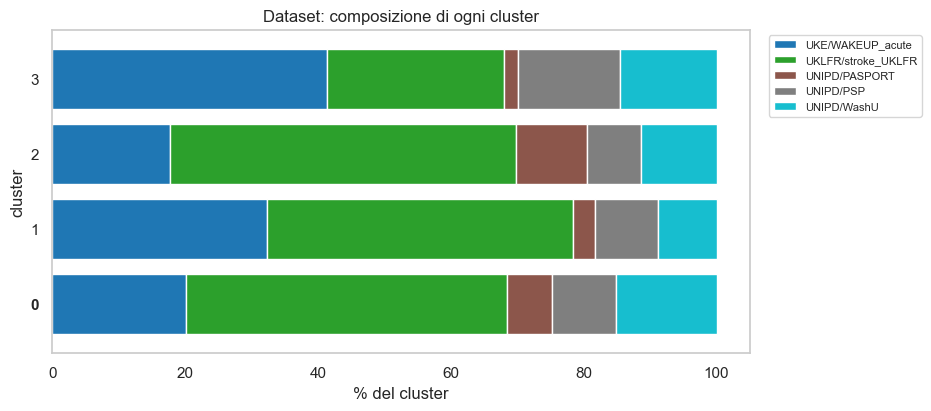

lesion_side,both,left,right
cluster_label,,,
0,4,3,414
1,9,467,0
2,3,279,0
3,11,135,244


Lato della lesione: V di Cramér = 0.614, p = 1.49e-252, soggetti con valore = 1569/1570


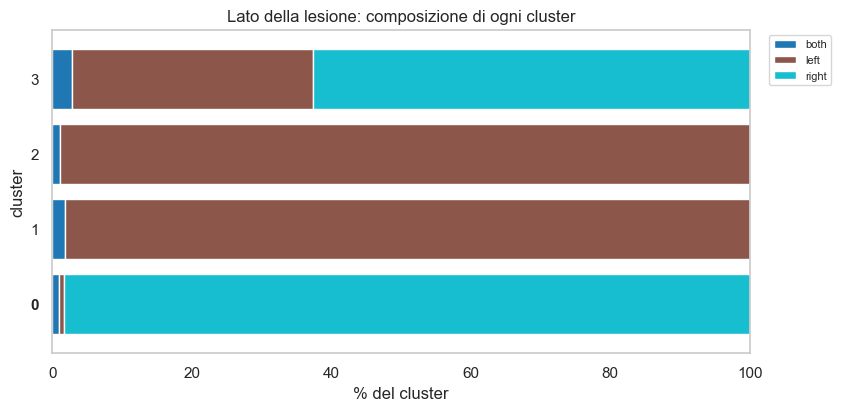

In [11]:
for column, title in [("dataset", "Dataset"), ("lesion_side", "Lato della lesione")]:
    counts, row_pct = composition_counts(column)
    display(counts)
    v, p_value = cramers_v(counts)
    print(f"{title}: V di Cramér = {v:.3f}, p = {p_value:.2e}, soggetti con valore = {int(counts.to_numpy().sum())}/{len(frame)}")
    plot_composition(row_pct, f"{title}: composizione di ogni cluster")

Localizzazione dominante: V di Cramér = 0.259, p = 2.99e-58, soggetti con valore = 1566/1570


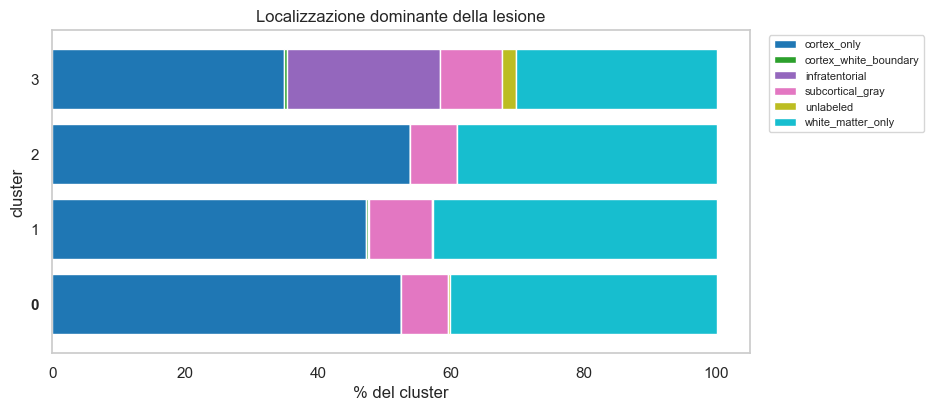

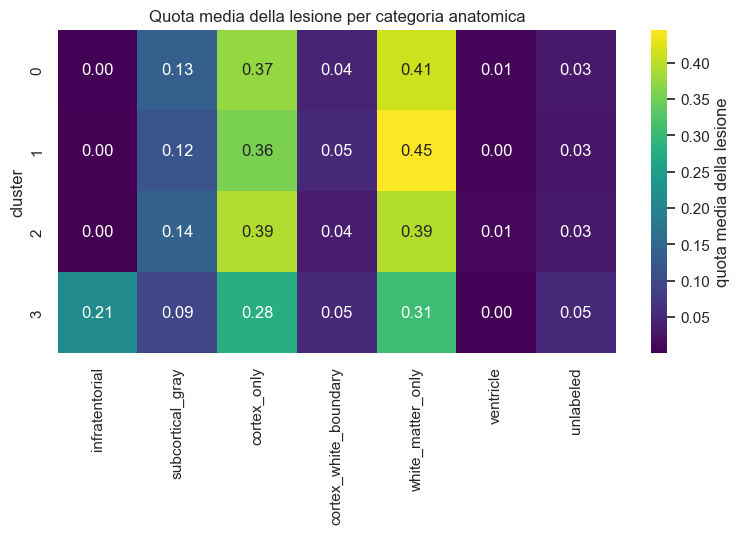

In [12]:
counts, row_pct = composition_counts("location_dominant")
v, p_value = cramers_v(counts)
print(f"Localizzazione dominante: V di Cramér = {v:.3f}, p = {p_value:.2e}, soggetti con valore = {int(counts.to_numpy().sum())}/{len(frame)}")
plot_composition(row_pct, "Localizzazione dominante della lesione")

fractions = frame.groupby("cluster_label")[[f"loc_{name}" for name in LOCATION_FRACTION_COLUMNS]].mean()
fractions.columns = list(LOCATION_FRACTION_COLUMNS)
fig, ax = plt.subplots(figsize=(9, 0.55 * len(fractions) + 2))
sns.heatmap(fractions, annot=True, fmt=".2f", cmap="viridis", cbar_kws={"label": "quota media della lesione"}, ax=ax)
ax.set_title("Quota media della lesione per categoria anatomica")
ax.set_ylabel("cluster")
plt.show()

## 5. Mappe anatomiche del cluster

Tutte sulla griglia 2mm, con i soggetti del cluster scelto. Un soggetto senza file sul disco è escluso e nominato:
`n` è il numero di soggetti realmente usati, lo stesso denominatore della percentuale.

- **Overlap della lesione**: per voxel, la % di soggetti del cluster con la lesione lì (maschere binarizzate a
  `binarize_threshold`). È già una probabilità: la frazione di soggetti. Un voxel vicino al 100% è una firma
  anatomica condivisa; nessun voxel caldo = cluster anatomicamente eterogeneo.
- **Disconnessione (solo run `sdc`)**, due letture degli stessi soggetti:
  - *% soggetti disconnessi*: ogni disconnettoma è binarizzato a `DISCONNECTION_PROBABILITY_THRESHOLD` e poi si conta,
    quindi è la stessa grandezza dell'overlap della lesione, direttamente confrontabile.
  - *Probabilità media*: media delle probabilità continue. Usa tutta l'informazione e vede la disconnessione diffusa
    sotto soglia, ma non è una % di soggetti: 0.6 può essere "tutti a 0.6" oppure "60% a 1 e 40% a 0".

### 5.1 Overlap della lesione

cluster 0: n=421 | picco 38.0% (160/421 soggetti) a MNI (28, -8, 12)


/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*args, out=...)


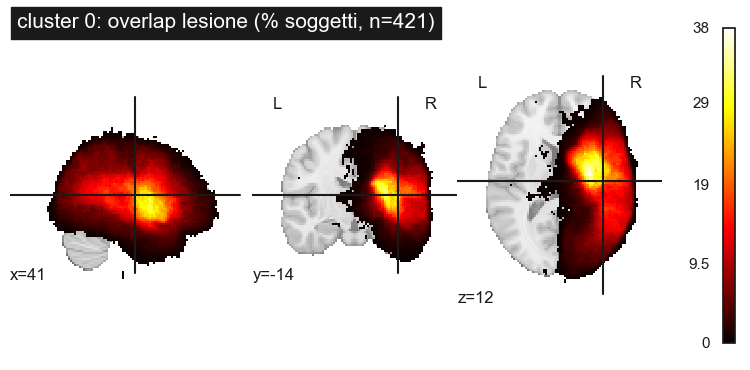

In [13]:
cluster_subjects = metadata.loc[metadata["cluster_label"] == CLUSTER]
lesion_count_img, lesion_pct_img, n_lesion, missing = lesion_overlap(cluster_subjects)
report_missing(missing)
peak_value, peak_xyz = peak(lesion_pct_img)
print(f"cluster {CLUSTER}: n={n_lesion} | picco {peak_value:.1f}% ({round(peak_value * n_lesion / 100)}/{n_lesion} soggetti) a MNI {peak_xyz}")
show_map(lesion_pct_img, f"cluster {CLUSTER}: overlap lesione (% soggetti, n={n_lesion})", cmap="hot", threshold=1e-6)

### 5.2 Disconnessione

cluster 0: n=421 | picco 90.5% a MNI (32, -14, 24) (soglia per soggetto > 0.5)


/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*args, out=...)


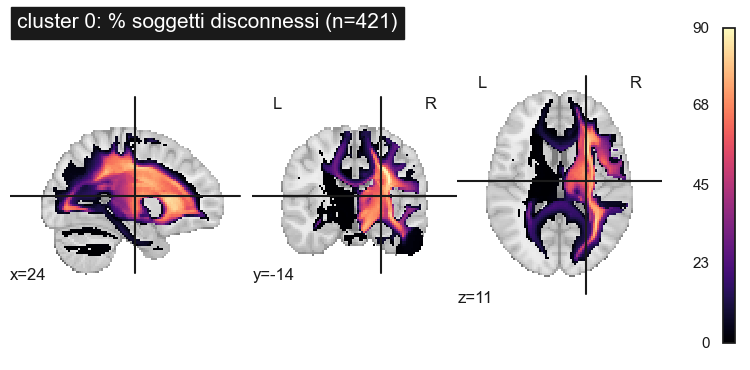

In [14]:
if SHOW_SDC_MAPS:
    sdc_count_img, sdc_pct_img, sdc_mean_img, n_sdc, missing = sdc_maps(cluster_subjects)
    report_missing(missing)
    peak_value, peak_xyz = peak(sdc_pct_img)
    print(f"cluster {CLUSTER}: n={n_sdc} | picco {peak_value:.1f}% a MNI {peak_xyz} (soglia per soggetto > {DISCONNECTION_PROBABILITY_THRESHOLD})")
    show_map(sdc_pct_img, f"cluster {CLUSTER}: % soggetti disconnessi (n={n_sdc})", cmap="magma", threshold=1e-6)
else:
    print("SHOW_SDC_MAPS è False (run non sdc): mappe di disconnessione non calcolate.")

cluster 0: n=421 | picco della probabilità media 0.87 a MNI (32, -14, 28)


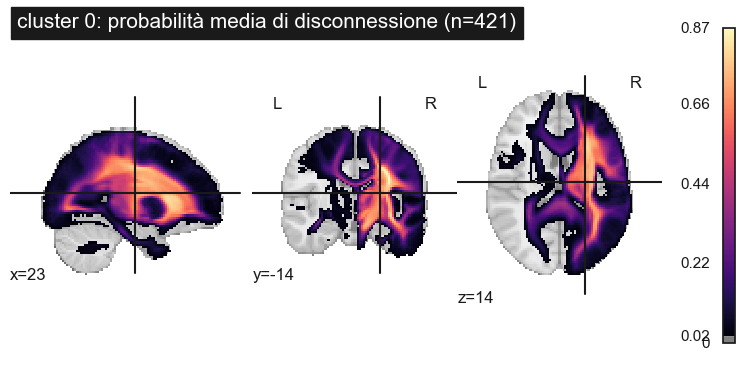

In [15]:
if SHOW_SDC_MAPS:
    peak_value, peak_xyz = peak(sdc_mean_img)
    print(f"cluster {CLUSTER}: n={n_sdc} | picco della probabilità media {peak_value:.2f} a MNI {peak_xyz}")
    show_map(sdc_mean_img, f"cluster {CLUSTER}: probabilità media di disconnessione (n={n_sdc})", cmap="magma", threshold=0.02)

### 5.3 Differenza cluster − resto

Le mappe sopra sono dominate dai siti di lesione comuni a tutti i cluster (territori frequenti): spesso mostrano
quanto è comune un voxel, non quanto è specifico del cluster. Qui, per voxel, **% nel cluster meno % nel resto
della run** (punti percentuali).

- Rosso = più frequente nel cluster, blu = meno frequente. Sotto `DIFFERENCE_THRESHOLD` punti il voxel non è colorato.
- È descrittiva: nessun test per voxel, quindi non indica significatività.
- La prima esecuzione legge ogni soggetto della run (poi restano in memoria): per una run di migliaia di soggetti
  può richiedere alcuni minuti.

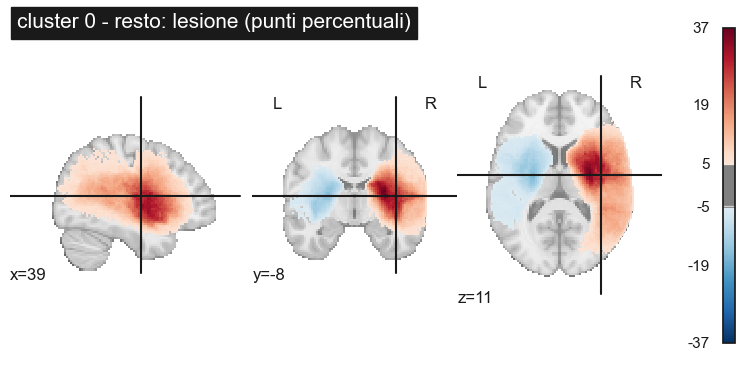

In [16]:
lesion_difference_img = difference_map(lesion_count_img, n_lesion, "lesion")
show_map(
    lesion_difference_img, f"cluster {CLUSTER} - resto: lesione (punti percentuali)",
    cmap="RdBu_r", threshold=DIFFERENCE_THRESHOLD, symmetric=True,
)

/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*args, out=...)


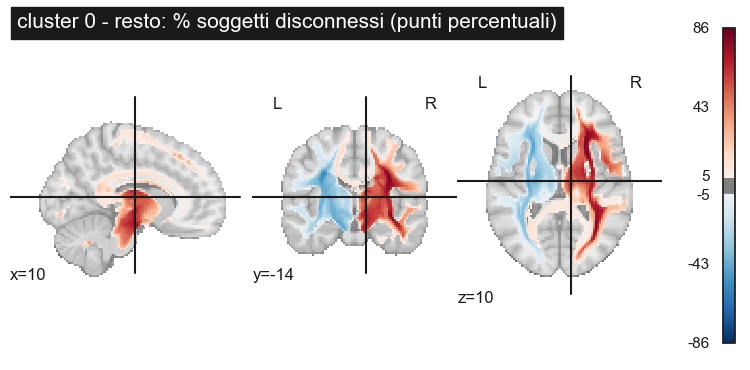

In [17]:
if SHOW_SDC_MAPS:
    sdc_difference_img = difference_map(sdc_count_img, n_sdc, "sdc")
    show_map(
        sdc_difference_img, f"cluster {CLUSTER} - resto: % soggetti disconnessi (punti percentuali)",
        cmap="RdBu_r", threshold=DIFFERENCE_THRESHOLD, symmetric=True,
    )

## 6. Soggetti rappresentativi

I `N_REPRESENTATIVE` soggetti reali più vicini al centroide del cluster, nello spazio dell'embedding, con la loro
mappa vera (lesione e, se `SHOW_SDC_MAPS`, disconnettoma) e le variabili del registro.

Il centroide è una media: su cluster non convessi può cadere fuori dal cluster e i "più vicini" non sono tipici in
senso statistico. Serve a farsi un'idea concreta, non a riassumere. Richiede un embedding 2D o 3D: su una run
clusterizzata sulla matrice grezza la sezione si ferma con un messaggio.

,subject_id,dataset,distance_to_centroid,age,sex,nihss,lesion_side,location_dominant
0,sub-STUKLFR0607,UKLFR/stroke_UKLFR,0.131809,55.0,M,3.0,right,cortex_only
1,sub-STUKLFR0210,UKLFR/stroke_UKLFR,0.180149,80.0,F,8.0,right,cortex_only
2,sub-STUKLFR0340,UKLFR/stroke_UKLFR,0.180315,87.0,F,1.0,right,cortex_only


/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*args, out=...)


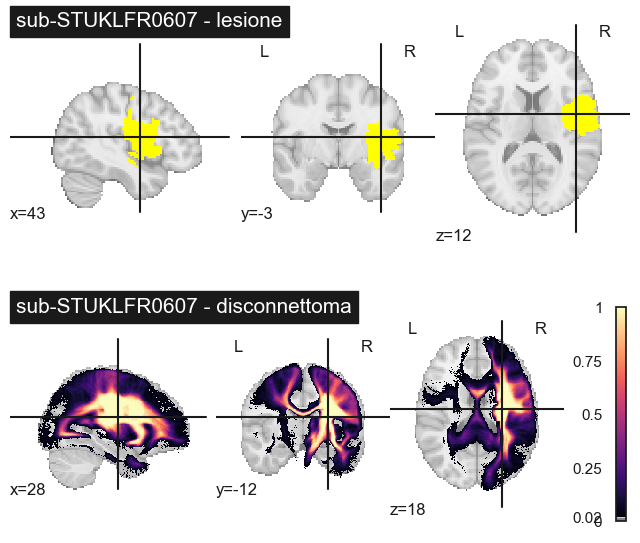

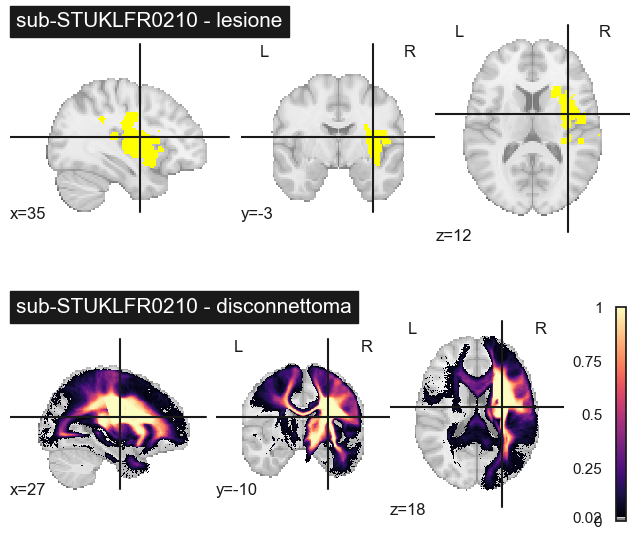

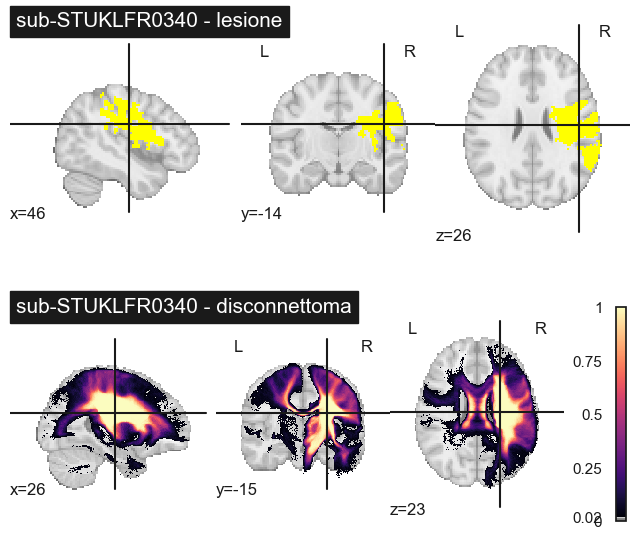

In [18]:
N_REPRESENTATIVE = 3

try:
    embedding, _metadata = load_run(run)
except UndisplayableRunError as error:
    print(f"sezione non disponibile: {error}")
else:
    representatives = nearest_subjects(embedding, CLUSTER, N_REPRESENTATIVE)
    display(representatives.merge(frame.drop(columns=["cluster_label", "dataset"]), on="subject_id", how="left")[
        ["subject_id", "dataset", "distance_to_centroid", "age", "sex", "nihss", "lesion_side", "location_dominant"]
    ])
    for row in representatives.itertuples():
        plot_subject_maps(row.subject_id, row.dataset, with_sdc=SHOW_SDC_MAPS)

## 7. Cluster contro resto

Una tabella per leggere in un colpo cosa distingue il cluster scelto da tutti gli altri soggetti della run.

- **Variabili continue** (età, istruzione, NIHSS, volume, disconnessione, quote di localizzazione): Mann-Whitney U
  bilaterale. L'effect size è la correlazione rank-biserial `r` in [-1, 1]: positiva = valori più alti nel cluster, 0 =
  nessuna differenza. Sono riportate anche le mediane.
- **Variabili categoriche** (sesso, dataset, lato, localizzazione dominante): una riga per categoria, test esatto di
  Fisher della categoria contro tutte le altre. Si legge soprattutto `share_cluster` contro `share_rest`; l'odds ratio
  è > 1 se la categoria è più frequente nel cluster.
- `p_fdr`: `p` corretto per test multipli (Benjamini-Hochberg) su tutte le righe insieme. Con migliaia di soggetti quasi
  tutto è significativo: ordina per effect size, non per `p`.
- Le righe con meno di 2 soggetti validi per lato restano con valori vuoti, non sono scartate.

In [19]:
def cluster_vs_rest(cluster_label: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    """(tabella continue, tabella categoriche) del cluster contro tutti gli altri soggetti della run, con p corretto
    per test multipli (Benjamini-Hochberg) su tutte le righe di entrambe le tabelle."""
    in_cluster = (frame["cluster_label"] == cluster_label).to_numpy()
    if in_cluster.all() or not in_cluster.any():
        raise ValueError(f"il cluster {cluster_label} è vuoto o coincide con tutta la run: niente da confrontare")

    continuous = [(v.name, v.label) for v in VARIABLES if v.kind == "continuous"]
    continuous += [(f"loc_{name}", f"quota {name}") for name in LOCATION_FRACTION_COLUMNS]
    continuous_rows = []
    for column, label in continuous:
        inside, rest = frame.loc[in_cluster, column].dropna(), frame.loc[~in_cluster, column].dropna()
        row = {"variabile": label, "n_cluster": len(inside), "n_rest": len(rest),
               "median_cluster": inside.median(), "median_rest": rest.median(), "r": np.nan, "p": np.nan}
        if len(inside) >= 2 and len(rest) >= 2:
            u_statistic, row["p"] = stats.mannwhitneyu(inside, rest, alternative="two-sided")
            row["r"] = 2 * u_statistic / (len(inside) * len(rest)) - 1
        continuous_rows.append(row)

    categorical = [("sex", "sesso")] + [(name, name) for name in CATEGORICAL_COLUMNS]
    categorical_rows = []
    for column, label in categorical:
        values = frame[column].replace("", np.nan)
        valid = values.notna().to_numpy()
        for category in sorted(values[valid].unique()):
            has = (values == category).to_numpy()
            table = [[(has & in_cluster).sum(), (~has & valid & in_cluster).sum()],
                     [(has & ~in_cluster).sum(), (~has & valid & ~in_cluster).sum()]]
            n_cluster, n_rest = sum(table[0]), sum(table[1])
            row = {"variabile": label, "categoria": category, "n_cluster": n_cluster, "n_rest": n_rest,
                   "share_cluster": np.nan, "share_rest": np.nan, "odds_ratio": np.nan, "p": np.nan}
            if n_cluster >= 2 and n_rest >= 2:
                row["share_cluster"], row["share_rest"] = table[0][0] / n_cluster, table[1][0] / n_rest
                row["odds_ratio"], row["p"] = stats.fisher_exact(table)
            categorical_rows.append(row)

    continuous_df, categorical_df = pd.DataFrame(continuous_rows), pd.DataFrame(categorical_rows)
    all_p = pd.concat([continuous_df["p"], categorical_df["p"]], ignore_index=True)
    valid_p = all_p.notna().to_numpy()
    adjusted = np.full(len(all_p), np.nan)
    adjusted[valid_p] = stats.false_discovery_control(all_p[valid_p].to_numpy(), method="bh")
    continuous_df["p_fdr"] = adjusted[: len(continuous_df)]
    categorical_df["p_fdr"] = adjusted[len(continuous_df):]
    return continuous_df, categorical_df

In [20]:
continuous_vs_rest, categorical_vs_rest = cluster_vs_rest(CLUSTER)
print(f"cluster {CLUSTER} contro il resto della run (n={int((frame['cluster_label'] == CLUSTER).sum())} contro {int((frame['cluster_label'] != CLUSTER).sum())})")
display(continuous_vs_rest.assign(abs_r=continuous_vs_rest["r"].abs()).sort_values("abs_r", ascending=False).drop(columns="abs_r").set_index("variabile").round(3))

cluster 0 contro il resto della run (n=421 contro 1149)


,n_cluster,n_rest,median_cluster,median_rest,r,p,p_fdr
variabile,,,,,,,
"Carico di disconnessione (voxel, 2mm)",421,1149,18990.393,8741.309,0.491,0.000,0.000
Disconnessione media (2mm),421,1149,0.083,0.038,0.491,0.000,0.000
Volume lesione (voxel),421,1149,3231.000,654.000,0.461,0.000,0.000
quota subcortical_gray,421,1145,0.047,0.000,0.263,0.000,0.000
quota ventricle,421,1145,0.000,0.000,0.225,0.000,0.000
NIHSS,406,1099,5.000,4.000,0.138,0.000,0.000
quota unlabeled,421,1145,0.024,0.018,0.112,0.001,0.002
quota cortex_white_boundary,421,1145,0.043,0.034,0.107,0.001,0.002
quota cortex_only,421,1145,0.447,0.353,0.099,0.003,0.006


In [21]:
effect = (categorical_vs_rest["share_cluster"] - categorical_vs_rest["share_rest"]).abs()
display(categorical_vs_rest.assign(abs_diff=effect).sort_values("abs_diff", ascending=False).drop(columns="abs_diff").set_index(["variabile", "categoria"]).round(3))

n_cluster  n_rest  share_cluster  \
variabile         categoria                                                 
lesion_side       right                        421    1148          0.983   
                  left                         421    1148          0.007   
dataset           UKE/WAKEUP_acute             421    1149          0.202   
sesso             F                            421    1146          0.470   
                  M                            421    1146          0.530   
location_dominant infratentorial               421    1145          0.000   
                  cortex_only                  421    1145          0.525   
dataset           UKLFR/stroke_UKLFR           421    1149          0.482   
                  UNIPD/WashU                  421    1149          0.152   
location_dominant white_matter_only            421    1145          0.401   
dataset           UNIPD/PASPORT                421    1149          0.069   
location_dominant subcortical_gray             421    1145          0.071   
dataset           UNIPD/PSP                    421    1149          0.095   
lesion_side       both                         421    1148          0.010   
location_dominant unlabeled                    421    1145          0.002   
                  cortex_white_boundary        421    1145          0.000   

                                         share_rest  odds_ratio      p  p_fdr  
variabile         categoria                                                    
lesion_side       right                       0.213     219.119  0.000  0.000  
                  left                        0.767       0.002  0.000  0.000  
dataset           UKE/WAKEUP_acute            0.319       0.541  0.000  0.000  
sesso             F                           0.386       1.414  0.003  0.006  
                  M                           0.614       0.707  0.003  0.006  
location_dominant infratentorial              0.079       0.000  0.000  0.000  
                  cortex_only                 0.447       1.366  0.007  0.012  
dataset           UKLFR/stroke_UKLFR          0.409       1.345  0.011  0.018  
                  UNIPD/WashU                 0.114       1.393  0.047  0.072  
location_dominant white_matter_only           0.376       1.115  0.349  0.405  
dataset           UNIPD/PASPORT               0.047       1.500  0.098  0.135  
location_dominant subcortical_gray            0.088       0.793  0.305  0.368  
dataset           UNIPD/PSP                   0.111       0.837  0.407  0.451  
lesion_side       both                        0.020       0.469  0.191  0.252  
location_dominant unlabeled                   0.008       0.301  0.305  0.368  
                  cortex_white_boundary       0.003       0.000  0.568  0.589

## 8. Dal notebook all'app

| Analisi | Nell'app Dash | Dove vive il codice |
|---|---|---|
| Tabella di confronto tra cluster (5 variabili) | sì | `cluster_description.clusters_comparison_stats` |
| Figura del cluster (box plot, barre) | sì | `cluster_description.build_cluster_description_figure` |
| Overlap della lesione per cluster | sì | `anatomical_maps.build_overlap_map` |
| Disconnessione per cluster (% soggetti, media) | sì | `build_overlap_map`, `build_mean_map` |
| Soggetto rappresentativo | sì, uno solo | `embedding_app.cluster_centroids_with_nearest_subject` |
| Carico e media di disconnessione nella tabella | solo qui | `EXTRA_VARIABLES` (sezione Utils) |
| Composizione per dataset, lato, localizzazione | solo qui | `composition_counts`, `cramers_v` |
| Mappa differenza cluster − resto | solo qui | `difference_map` |
| Cluster contro resto (test, effect size) | solo qui | `cluster_vs_rest` |

Per portare un'analisi nell'app: la funzione passa da qui a `src/analysis/` con i test, poi il pannello la chiama.